# STID Multivariate Forecasting — lon / lat / alt

This notebook trains the **official STID** model from the paper
[*Spatial-Temporal Identity: A Simple yet Effective Baseline for Multivariate Time Series Forecasting*](https://arxiv.org/abs/2208.05233)
(CIKM 2022) on the `italy_flights_20k` dataset.

The model code is taken **directly** from the official repository:
[https://github.com/GestaltCogTeam/STID](https://github.com/GestaltCogTeam/STID)
(cloned into `STID-git/` in this directory).

**STID treats each feature (lon, lat, alt) as a separate "node"** and uses:
- A learnable spatial (node) embedding per feature
- A learnable temporal embedding for time-of-day
- A learnable temporal embedding for day-of-week
- A stack of MLP layers with residual connections

- **Input (context):** 60 time-steps of `[lon, lat, alt]` (~10 min at 10 s spacing)
- **Output (forecast):** next 12 time-steps of `[lon, lat, alt]` (~2 min)
- Flights with fewer than 200 observations are dropped.
- Per-flight `StandardScaler` is applied before training.
- Train / test split: 70 % / 30 % per flight.

## 0. Imports

In [23]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Point Python at the official STID repo ──────────────────────────────────
# Notebooks run with CWD = Forecasting_Baseline/
STID_REPO = os.path.abspath('STID-git')
if STID_REPO not in sys.path:
    sys.path.insert(0, STID_REPO)

# ── Import the official STID model ───────────────────────────────────────────
from stid.arch import STID  # official code

print('STID imported from:', STID_REPO)
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print('Device:', device)

STID imported from: /Users/mayaeidelman/Documents/tahoe-research/Forecasting_Baseline/STID-git
Device: mps


## 1. Load data

In [24]:
df = pd.read_parquet('../data/italy_flights_20k.parquet')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

print(f'Total rows: {len(df):,}')
print(f'Unique flights: {df["track_id"].nunique():,}')
df.head()

Total rows: 2,493,533
Unique flights: 13,919


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30


## 2. Build per-flight arrays

In [25]:
MIN_LENGTH = 200
FEATURES   = ['lon', 'lat', 'alt']

flights_data = []   # list of (values_array [T,3], timestamps_array [T])
skipped = 0

for track_id, g in df.groupby('track_id'):
    g = g.sort_values('datetime').drop_duplicates(subset='datetime')

    if len(g) < MIN_LENGTH:
        skipped += 1
        continue

    vals = g[FEATURES].values.astype(np.float32)   # [T, 3]
    ts   = g['datetime'].values                    # [T] datetime64

    if np.isnan(vals).any():
        skipped += 1
        continue

    flights_data.append((vals, ts))

print(f'Kept: {len(flights_data)} flights  |  Skipped: {skipped}')

Kept: 5828 flights  |  Skipped: 8091


## 3. Scale & split

In [26]:
TRAIN_FRAC = 0.7

train_flights = []   # list of (scaled_values [T,3], timestamps [T])
test_flights  = []
scalers       = []

for vals, ts in flights_data:
    split = int(len(vals) * TRAIN_FRAC)

    scaler = StandardScaler()
    train_sc = scaler.fit_transform(vals[:split]).astype(np.float32)
    test_sc  = scaler.transform(vals[split:]).astype(np.float32)

    train_flights.append((train_sc, ts[:split]))
    test_flights.append((test_sc,   ts[split:]))
    scalers.append(scaler)

print(f'Train flights: {len(train_flights)}  |  Test flights: {len(test_flights)}')

Train flights: 5828  |  Test flights: 5828


## 4. Build temporal index features

STID uses two discrete temporal embeddings looked up by index:

| Channel | Meaning | Encoding |
|---------|---------|----------|
| `..., 1` | **time-of-day** | normalised to `[0, 1)` → multiplied by `time_of_day_size` internally |
| `..., 2` | **day-of-week** | normalised to `[0, 1)` → multiplied by `day_of_week_size` internally |

For 10 s data: `time_of_day_size = 86400 / 10 = 8640`.

In [27]:
FREQ_SEC         = 10
TIME_OF_DAY_SIZE = 86400 // FREQ_SEC   # 8640 slots per day
DAY_OF_WEEK_SIZE = 7

def make_stid_temporal(ts_array):
    """Return float32 array of shape [T, 2]:
       col 0 = time_of_day  in [0, 1)
       col 1 = day_of_week  in [0, 1)
    """
    ts = pd.DatetimeIndex(ts_array)
    seconds_in_day = np.array(ts.hour * 3600 + ts.minute * 60 + ts.second, dtype=np.float32)
    tod = (seconds_in_day / FREQ_SEC) / TIME_OF_DAY_SIZE   # [0, 1)  plain numpy
    dow = np.array(ts.dayofweek, dtype=np.float32) / DAY_OF_WEEK_SIZE   # [0, 1)  plain numpy
    return np.stack([tod, dow], axis=1).astype(np.float32)  # [T, 2]


## 5. Build sliding-window dataset

STID expects tensors with shape `[B, L, N, C]` where:
- `B` = batch size
- `L` = sequence length
- `N` = num_nodes = 3 (lon, lat, alt)
- `C` = 3 channels: `[value, time_of_day, day_of_week]`

In [28]:
INPUT_LEN  = 60
OUTPUT_LEN = 12
WINDOW     = INPUT_LEN + OUTPUT_LEN
N_NODES    = 3   # lon, lat, alt

def build_windows(flights):
    """Return (X, Y) tensors with X shape [W, INPUT_LEN, N_NODES, 3]
    and Y shape [W, OUTPUT_LEN, N_NODES, 1].
    X channels: [scaled_value, time_of_day_norm, day_of_week_norm]
    """
    xs, ys = [], []
    for vals, ts in flights:          # vals [T, 3], ts [T]
        temporal = make_stid_temporal(ts)   # [T, 2]
        T = len(vals)
        for start in range(0, T - WINDOW + 1):
            end_in  = start + INPUT_LEN
            end_out = start + WINDOW

            v_in  = vals[start:end_in]        # [INPUT_LEN, 3]
            t_in  = temporal[start:end_in]    # [INPUT_LEN, 2]
            v_out = vals[end_in:end_out]       # [OUTPUT_LEN, 3]

            # Build X: [INPUT_LEN, N_NODES, 3]
            # Each node gets its own value + shared temporal features
            x = np.stack([
                np.stack([v_in[:, i], t_in[:, 0], t_in[:, 1]], axis=1)  # [INPUT_LEN, 3]
                for i in range(N_NODES)
            ], axis=1)   # [INPUT_LEN, N_NODES, 3]

            # Build Y: [OUTPUT_LEN, N_NODES, 1]  (values only)
            # v_out is [OUTPUT_LEN, N_NODES], add trailing dim then it's [OUTPUT_LEN, N_NODES, 1]
            y = v_out[:, :, np.newaxis]   # [OUTPUT_LEN, N_NODES, 1]

            xs.append(x)
            ys.append(y)

    X = torch.tensor(np.stack(xs), dtype=torch.float32)   # [W, INPUT_LEN,  N_NODES, 3]
    Y = torch.tensor(np.stack(ys), dtype=torch.float32)   # [W, OUTPUT_LEN, N_NODES, 1]
    return X, Y

print('Building training windows...')
X_train, Y_train = build_windows(train_flights)
print(f'Train windows: {X_train.shape[0]:,}  X={X_train.shape}  Y={Y_train.shape}')

print('Building test windows...')
X_test,  Y_test  = build_windows(test_flights)
print(f'Test  windows: {X_test.shape[0]:,}  X={X_test.shape}  Y={Y_test.shape}')

Building training windows...
Train windows: 760,038  X=torch.Size([760038, 60, 3, 3])  Y=torch.Size([760038, 12, 3, 1])
Building test windows...
Test  windows: 100,103  X=torch.Size([100103, 60, 3, 3])  Y=torch.Size([100103, 12, 3, 1])


## 6. Instantiate the official STID model

In [29]:
model_args = dict(
    num_nodes        = N_NODES,           # 3 features treated as nodes
    node_dim         = 32,                # spatial embedding dim
    input_len        = INPUT_LEN,         # 60
    input_dim        = 1,                 # 1 value per node (temporal feats separate)
    embed_dim        = 32,                # time-series embedding dim
    output_len       = OUTPUT_LEN,        # 12
    num_layer        = 3,                 # number of MLP layers
    temp_dim_tid     = 32,                # time-of-day embedding dim
    temp_dim_diw     = 32,                # day-of-week embedding dim
    time_of_day_size = TIME_OF_DAY_SIZE,  # 8640
    day_of_week_size = DAY_OF_WEEK_SIZE,  # 7
    if_T_i_D         = True,              # use time-of-day embedding
    if_D_i_W         = True,              # use day-of-week embedding
    if_node          = True,              # use spatial (node) embedding
)

model = STID(**model_args).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'STID trainable parameters: {n_params:,}')

STID trainable parameters: 379,372


## 7. Train the model

In [30]:
N_EPOCHS   = 3
BATCH_SIZE = 64
LR         = 1e-3

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)   # [B, INPUT_LEN, N_NODES, 3]
        yb = yb.to(device)   # [B, OUTPUT_LEN, N_NODES, 1]

        # STID forward: history_data=[B,L,N,C], future_data not used in inference
        pred = model(
            history_data=xb,
            future_data=None,
            batch_seen=0,
            epoch=epoch,
            train=True,
        )   # [B, OUTPUT_LEN, N_NODES, 1]

        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    avg = epoch_loss / len(X_train)
    print(f'Epoch {epoch:02d}/{N_EPOCHS}  train_loss={avg:.6f}')

print('Training complete.')

Epoch 01/3  train_loss=0.151942


KeyboardInterrupt: 

## 8. Evaluate on test set

In [31]:
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=512,
    shuffle=False,
)

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(
            history_data=xb,
            future_data=None,
            batch_seen=0,
            epoch=0,
            train=False,
        ).cpu()   # [B, OUTPUT_LEN, N_NODES, 1]
        all_preds.append(pred)
        all_true.append(yb)

all_preds = torch.cat(all_preds)   # [N_total, OUTPUT_LEN, N_NODES, 1]
all_true  = torch.cat(all_true)

mse_val = ((all_preds - all_true) ** 2).mean().item()
mae_val = (all_preds - all_true).abs().mean().item()

print(f'Test MSE: {mse_val:.6f}')
print(f'Test MAE: {mae_val:.6f}')

Test MSE: 291487.687500
Test MAE: 45.359608


## 9. Per-feature time-series plot

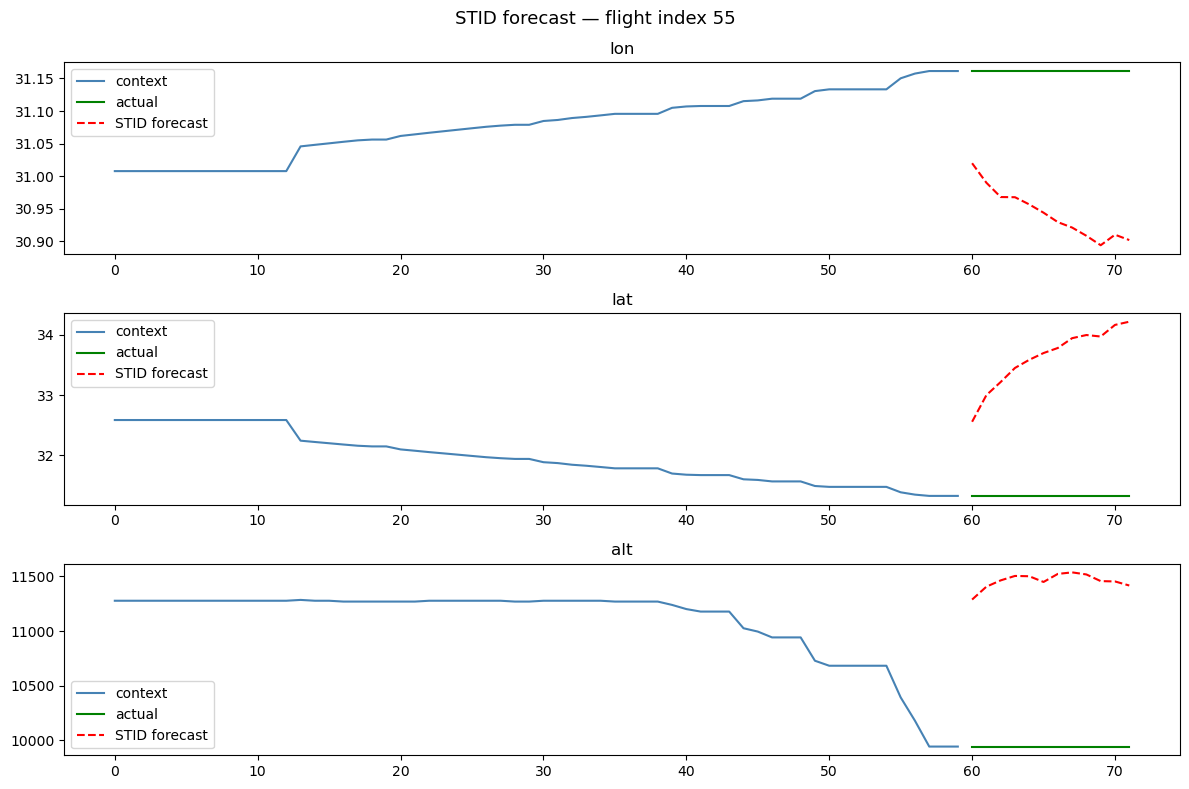

In [32]:
SAMPLE_IDX = 55   # change to inspect a different flight

test_vals, test_ts = test_flights[SAMPLE_IDX]
scaler             = scalers[SAMPLE_IDX]

if len(test_vals) < INPUT_LEN + OUTPUT_LEN:
    raise ValueError('Flight too short; try a different SAMPLE_IDX.')

ctx_sc = test_vals[:INPUT_LEN]                         # [INPUT_LEN, 3]
act_sc = test_vals[INPUT_LEN:INPUT_LEN + OUTPUT_LEN]   # [OUTPUT_LEN, 3]
ctx_ts = test_ts[:INPUT_LEN]

# Build one-sample input tensor [1, INPUT_LEN, N_NODES, 3]
temporal = make_stid_temporal(ctx_ts)    # [INPUT_LEN, 2]
x_sample = np.stack([
    np.stack([ctx_sc[:, i], temporal[:, 0], temporal[:, 1]], axis=1)
    for i in range(N_NODES)
], axis=1)   # [INPUT_LEN, N_NODES, 3]

xb = torch.tensor(x_sample[np.newaxis], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    fct_sc = model(
        history_data=xb, future_data=None,
        batch_seen=0, epoch=0, train=False,
    ).cpu().numpy()[0]   # [OUTPUT_LEN, N_NODES, 1]

fct_sc = fct_sc[:, :, 0]   # [OUTPUT_LEN, N_NODES]

# Inverse-transform
ctx_orig = scaler.inverse_transform(ctx_sc)
act_orig = scaler.inverse_transform(act_sc)
fct_orig = scaler.inverse_transform(fct_sc)

ctx_x = np.arange(INPUT_LEN)
act_x = np.arange(INPUT_LEN, INPUT_LEN + OUTPUT_LEN)

feature_names = ['lon', 'lat', 'alt']
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, (ax, feat) in enumerate(zip(axes, feature_names)):
    ax.plot(ctx_x, ctx_orig[:, i], color='steelblue', label='context')
    ax.plot(act_x, act_orig[:, i], color='green',     label='actual')
    ax.plot(act_x, fct_orig[:, i], color='red', linestyle='--',
            label='STID forecast')
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f'STID forecast — flight index {SAMPLE_IDX}', fontsize=13)
plt.tight_layout()
plt.show()

## 10. 2-D trajectory plot (lon vs lat)

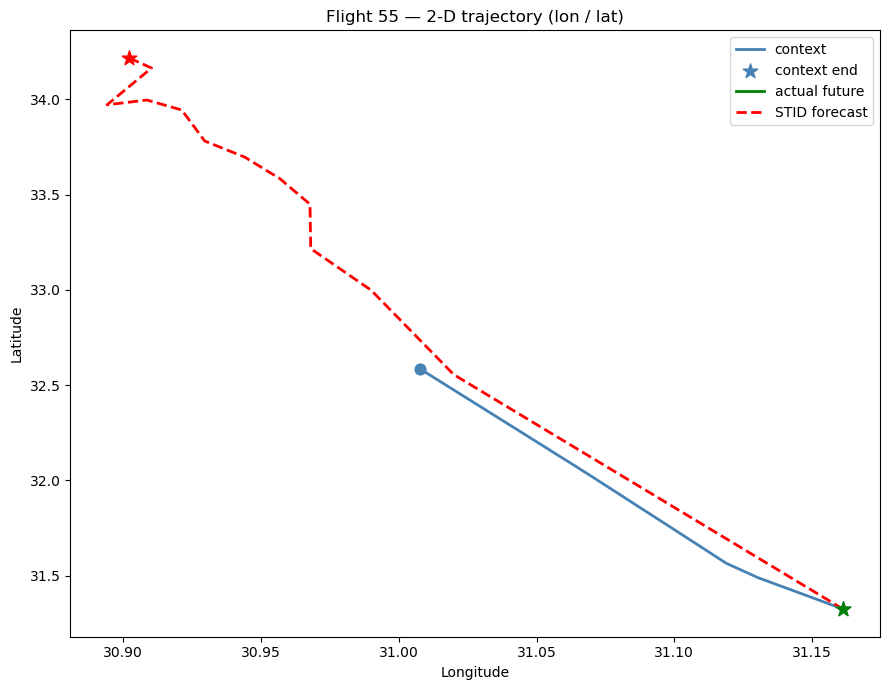

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(ctx_orig[:, 0], ctx_orig[:, 1],
        color='steelblue', linewidth=2, label='context')
ax.scatter(ctx_orig[0,  0], ctx_orig[0,  1], color='steelblue', s=60, zorder=5)
ax.scatter(ctx_orig[-1, 0], ctx_orig[-1, 1], color='steelblue', s=120,
           marker='*', zorder=5, label='context end')

ax.plot(
    [ctx_orig[-1, 0]] + list(act_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(act_orig[:, 1]),
    color='green', linewidth=2, label='actual future'
)
ax.scatter(act_orig[-1, 0], act_orig[-1, 1], color='green', s=120,
           marker='*', zorder=5)

ax.plot(
    [ctx_orig[-1, 0]] + list(fct_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(fct_orig[:, 1]),
    color='red', linewidth=2, linestyle='--', label='STID forecast'
)
ax.scatter(fct_orig[-1, 0], fct_orig[-1, 1], color='red', s=120,
           marker='*', zorder=5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Flight {SAMPLE_IDX} — 2-D trajectory (lon / lat)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. 3-D trajectory plot (lon, lat, alt)

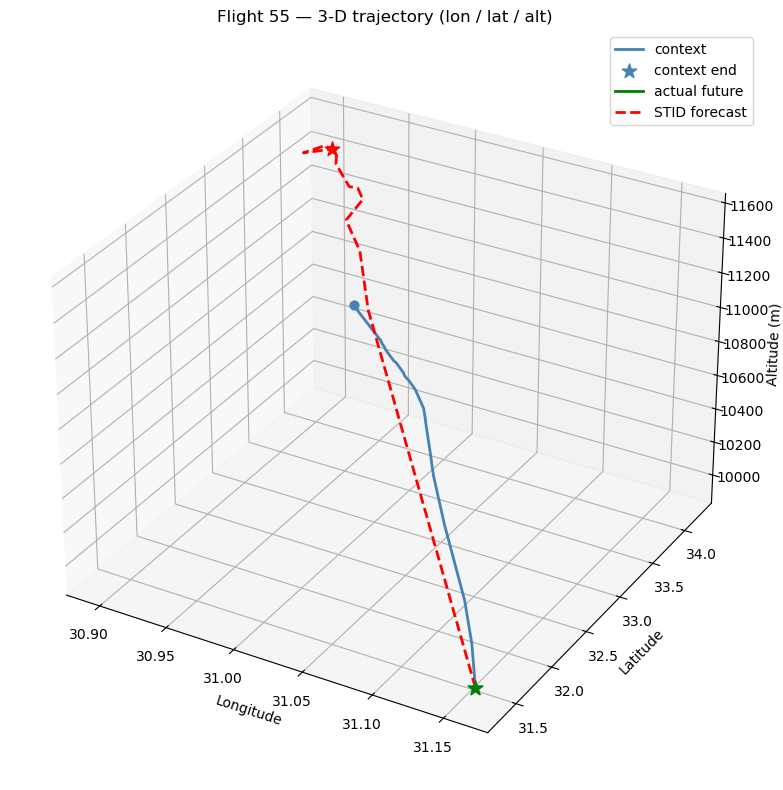

In [34]:
fig = plt.figure(figsize=(11, 8))
ax3 = fig.add_subplot(111, projection='3d')

ax3.plot(ctx_orig[:, 0], ctx_orig[:, 1], ctx_orig[:, 2],
         color='steelblue', linewidth=2, label='context')
ax3.scatter(*ctx_orig[0],  color='steelblue', s=40, zorder=5)
ax3.scatter(*ctx_orig[-1], color='steelblue', s=120,
            marker='*', zorder=5, label='context end')

bridge_act_lon = [ctx_orig[-1, 0]] + list(act_orig[:, 0])
bridge_act_lat = [ctx_orig[-1, 1]] + list(act_orig[:, 1])
bridge_act_alt = [ctx_orig[-1, 2]] + list(act_orig[:, 2])
ax3.plot(bridge_act_lon, bridge_act_lat, bridge_act_alt,
         color='green', linewidth=2, label='actual future')
ax3.scatter(*act_orig[-1], color='green', s=120, marker='*', zorder=5)

bridge_fct_lon = [ctx_orig[-1, 0]] + list(fct_orig[:, 0])
bridge_fct_lat = [ctx_orig[-1, 1]] + list(fct_orig[:, 1])
bridge_fct_alt = [ctx_orig[-1, 2]] + list(fct_orig[:, 2])
ax3.plot(bridge_fct_lon, bridge_fct_lat, bridge_fct_alt,
         color='red', linewidth=2, linestyle='--', label='STID forecast')
ax3.scatter(*fct_orig[-1], color='red', s=120, marker='*', zorder=5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.set_zlabel('Altitude (m)')
ax3.set_title(f'Flight {SAMPLE_IDX} — 3-D trajectory (lon / lat / alt)')
ax3.legend()
plt.tight_layout()
plt.show()

## 12. Save model weights

In [35]:
import os
os.makedirs('saved_models', exist_ok=True)
save_path = os.path.join('saved_models', 'stid.pt')
torch.save({
    'state_dict': model.state_dict(),
    'model_args': model_args,
}, save_path)
print(f'Model saved to {save_path}')


Model saved to saved_models/stid.pt
